尝试使用 agent 提取基本职官结构，包括
  * 类别信息
  * 上下级机构关系
  * 机构职官隶属关系
  * 相关事件信息

类别信息
  * type: 类别
  * class: 类别描述

上下级机构关系：
  * type: 上下级机构
  * parent: 上级机构
  * subordinate: 下级机构

机构编制关系
  * type: 编制
  * office: 机构
  * employee: 编制名称
  * number: 编制数量

相关事件信息
  * type: 事件
  * time: 时间点
  * event: 事件描述（始置时间，罢置时间，改名，改制等）

溯源引用信息
  * text: 原始描述
  * ref: 索引描述

In [2]:
import json

def  generate_prompt(entities):

  generate_prompt = f"""
你是一个专业的宋代职官信息分析专家，现在需要根据给定的材料，从中提取出结构化的职官信息，并标注详细的文献引用信息。
输入数据包括一组机构或职官的具体信息描述，每个条目包含多个字段的内容。
你需要从中提取出其中存在的：
1. 类别信息，即该机构或职官属于哪个类别；提取信息包含四个字段
  * type: 类别
  * target: 目标机构或官职等
  * class: 类别描述
  * cite: 引用信息
2. 上下级机构关系，即该机构隶属哪个机构，又统领哪些机构；提取信息包含四个字段
  * type: 上下级机构
  * parent: 上级机构
  * subordinate: 下级机构
  * cite: 引用信息
2. 机构中的编制信息，即该机构中设有哪些官职吏职，提取信息包含四个字段
  * type: 编制
  * office: 机构
  * employees: 编制信息
  * cite: 引用信息
3. 与职官编制，机构相关的事件信息，如始置时间，罢置时间，改名，改制等；提取信息包含五个字段
  * type: 事件
  * target: 目标机构或官职等
  * time: 时间点
  * event: 事件描述（始置时间，罢置时间，改名，改制等）
  * cite: 引用信息

注意，在一个条目中可能包含多个多种上述的信息，均需要进行提取。不属于上述信息的内容不需要提取。
其中引用信息包含两个字段
  * text: 原始描述文本，即提供的条目中相关的叙述文字
  * ref: 索引描述文本，即所引用的条目，字段等结构信息；所提供的条目均来自《宋代官制辞典》，这里仅需补充具体的条目和字段信息；例如 《宋代官制辞典》，河北兵马大元帅府，text

以下是一些提取案例：

条目信息：
```
{{
  "name": "河北兵马大元帅府",
  "简称": "①大元帅府、元帅府。《宋会要·职官》37之1：“高宗建炎元年五月二日，诏大元帅府限十日结局。”《要录》卷1靖康元年十一月己酉：“拜王（康王赵构)河北兵马大元帅。”十二月壬戌朔：“王开元帅府。”②帅府。《要录》卷1乙亥：“乃遣人伴送至帅府。”③霸府。《要录》卷1，靖康元年闰十一月己酉：“拜王河北兵马大元帅。”原注引《汪伯彦日历》：“然霸府肇启开，事出仓卒。盖靖康元年闰十一月，檄到日，康王可充兵马大元帅。”④天下兵马大元帅府。过称。《金佗粹编》卷4《行实编年》：“（靖康元年）冬，高宗皇帝以天下兵马大元帅开府河朔。”《要录》卷4，建炎元年四月癸亥：“（赵子崧）望大王遵故事，以天下兵马大元帅承制号召四方。”",
  "text": "官司名。北宋靖康元年闰十一月，宋钦宗传檄，授命康王为河北兵马大元帅。十二月一日，赵构开大元帅府，以募兵勤王抗金，解救京师之围为名（《要录》卷1）。南宋建炎元年五月十日大元帅府解散（《宋会要·职官》37之2《元帅府》）。"
}}
```

提取结果：
[
  {{
    "type": "类别",
    "target": "河北兵马大元帅府",
    "class": "官司",
    "cite": {{
      "text": "官司名。",
      "ref": "《宋代官制辞典》，河北兵马大元帅府，text"
    }}
  }},
  {{
    "type": "事件",
    "target": "河北兵马大元帅府",
    "time": "北宋靖康元年十二月一日",
    "event": "始置",
    "cite": {{
      "text": "北宋靖康元年闰十一月，宋钦宗传檄，授命康王为河北兵马大元帅。十二月一日，赵构开大元帅府，以募兵勤王抗金，解救京师之围为名（《要录》卷1）。",
      "ref": "《宋代官制辞典》，河北兵马大元帅府，text"
    }}
  }},
  {{
    "type": "事件",
    "target": "河北兵马大元帅府",
    "time": "南宋建炎元年五月十日",
    "event": "罢置",
    "cite": {{
      "text": "南宋建炎元年五月十日大元帅府解散（《宋会要·职官》37之2《元帅府》）。",
      "ref": "《宋代官制辞典》，河北兵马大元帅府，text"
    }}
  }}
]

条目信息：
```
{{
  "name": "河北兵马大元帅府都统制五军兵马",
  "简称": "都统制、都统制军马。《要录》卷2庚辰：“都统制陈淬曰：‘敌方炽，未可轻举。’（副元帅）泽怒，将斩之。诸将罗拜，乞代淬效死。”《宋史·高宗纪》1：“帝开大元帅府，有兵万人分为五军。”命武显大夫陈淬都统制军马。”《北盟会编》卷71：“（靖康元年十二月二日癸亥）兵马大元帅府都统制五军兵马。”",
  "text": "军职名。河北兵马大元帅府属官。元帅府五军实际统兵长官，位次于副元帅，在诸军统制官之上。大元帅府都统制二员。"
}},
```

提取结果：
[
  {{
    "type": "类别",
    "target": "河北兵马大元帅府都统制五军兵马",
    "class": "军职",
    "cite": {{
      "text": "军职名。",
      "ref": "《宋代官制辞典》，河北兵马大元帅府都统制五军兵马，text"
    }}
  }},
  {{
    "type": "编制",
    "office": "河北兵马大元帅府",
    "employees": "河北兵马大元帅府设有都统制五军兵马二员。",
    "cite": {{
      "text": "大元帅府都统制二员。",
      "ref": "《宋代官制辞典》，河北兵马大元帅府都统制五军兵马，text"
    }}
  }}
]

条目信息：
```
{{
  "name": "都督府",
  "编制": "都督府长官为都督、督视（同都督）。属官有谘议军事、参谋军事、参议军事、主管机宜文字、主管书写文字、干办公事、随军转运使、准备差使、准备将领等。以及人吏若干（《宋会要·职官》39之5、11）。",
  "简称与别名": "①督府。《朝野杂记》乙集卷14《绍兴至开禧督府废置本末》：“张德远以败刘貌之功同相，乃与（赵鼎）并兼都督诸路军马。……及上幸建康，则督府在内。”②都府。《要录》卷92己巳：“左宣奉大夫、守尚书右仆射兼知枢密院事、都督诸路军马张浚。……庚午，置潭州市易务，……其息钱非朝廷及都府指挥毋得擅用。”③帅府。《宋史·忠义·何时传》：“天祥起兵，辟署帅府机宜。”《宋史·忠义·刘子俊传》：“天祥开督府兴国，子俊诣府计事，补宣教郎、带行军器监簿兼督府机宜。”",
  "text": "官司名。"
}}
```

提取结果：
[
  {{
    "type": "类别",
    "target": "都督府",
    "class": "官司",
    "cite": {{
      "text": "官司名。",
      "ref": "《宋代官制辞典》，都督府，text"
    }}
  }},
  {{
    "type": "编制",
    "office": "都督府",
    "employees": "都督府设有长官都督、督视（同都督）。属官有谘议军事、参谋军事、参议军事、主管机宜文字、主管书写文字、干办公事、随军转运使、准备差使、准备将领等。以及人吏若干。",
    "cite": {{
      "text": "都督府长官为都督、督视（同都督）。属官有谘议军事、参谋军事、参议军事、主管机宜文字、主管书写文字、干办公事、随军转运使、准备差使、准备将领等。以及人吏若干（《宋会要·职官》39之5、11）。",
      "ref": "《宋代官制辞典》，都督府，编制"
    }}
  }}
]

以下为输入条目信息：

{json.dumps(entities, ensure_ascii=False, indent=2)}

输出为JSON格式，是一个列表，其中每个元素是一个字典，对应于上述提取结果类别中的一种。
要求：
1. 提取结果需要包含所有条目中的信息，不要遗漏；
2. 严格按照要求的提取结果格式输出，不要增加或遗漏字段；
3. 直接输出JSON格式，不要包含任何解释说明等内容。

"""
  return generate_prompt


In [3]:
test_entities = [
  {
    "name": "河北兵马大元帅府",
    "简称": "①大元帅府、元帅府。《宋会要·职官》37之1：“高宗建炎元年五月二日，诏大元帅府限十日结局。”《要录》卷1靖康元年十一月己酉：“拜王（康王赵构)河北兵马大元帅。”十二月壬戌朔：“王开元帅府。”②帅府。《要录》卷1乙亥：“乃遣人伴送至帅府。”③霸府。《要录》卷1，靖康元年闰十一月己酉：“拜王河北兵马大元帅。”原注引《汪伯彦日历》：“然霸府肇启开，事出仓卒。盖靖康元年闰十一月，檄到日，康王可充兵马大元帅。”④天下兵马大元帅府。过称。《金佗粹编》卷4《行实编年》：“（靖康元年）冬，高宗皇帝以天下兵马大元帅开府河朔。”《要录》卷4，建炎元年四月癸亥：“（赵子崧）望大王遵故事，以天下兵马大元帅承制号召四方。”",
    "text": "官司名。北宋靖康元年闰十一月，宋钦宗传檄，授命康王为河北兵马大元帅。十二月一日，赵构开大元帅府，以募兵勤王抗金，解救京师之围为名（《要录》卷1）。南宋建炎元年五月十日大元帅府解散（《宋会要·职官》37之2《元帅府》）。"
  },
  {
    "name": "河北兵马大元帅",
    "简称与别名": "①兵马大元帅。《要录》卷1丁酉：“拜王河北兵马大元帅。”注引《赵牲之遗史》：“康王可充兵马大元帅府。”②大元帅。《要录》卷1乙卯：“济州始存大元帅驻泊之地。”同前书卷癸未：“仰大元帅康王将天下兵，分屯近甸。”",
    "text": "军职名。北宋靖康元年闰十一月，命置。南宋建炎元年五月十日罢。由亲王担任，统率元帅府勤王兵、募兵五军万人之众（《要录》卷1）。"
  },
  {
    "name": "河北兵马元帅",
    "简称": "①元帅。《宋史·奸臣·汪伯彦》：“王奉蜡书，开天下兵马大元帅府，以伯彦为副将。升元帅。”《宋史·高宗纪》1：“钦宗遣阎门祗候秦仔持蜡诏至相（州），拜帝为河北兵马大元帅，知中山府陈亨伯为元帅。”②兵马元帅。《要录》卷4丁亥：“兵马元帅汪伯彦。”",
    "text": "军职名。靖康间康王赵构所开河北兵马大元帅府，设大元帅、元帅、副元帅（《宋史·高宗纪》1）。"
  },
  {
    "name": "河北兵马副元帅",
    "简称": "兵马副元帅、副元帅。《要录》卷3丙辰：“王承制，以集英殿修撰、兵马副元帅宗泽为徽猷阁待制。”《宋史·宗泽传》：“有诏以泽为副元帅。”《宋史·高宗纪》1：“钦宗遣阁门祗候秦仔持蜡诏至相，拜帝为河北兵马大元帅，知中山府陈亨伯为元帅，汪伯彦、宗泽为副元帅。”",
    "text": "军职名。靖康元年十二月一日置河北兵马大元帅府副元帅二员，次年（建炎元年）五月十日罢（《要录》卷1，《宋会要·职官》37之1、2）。"
  },
  {
    "name": "督视军马府参谋军事",
    "简称与别名": "①参谋军事。《宋史·虞允文传》：“枢臣叶义问督江、淮军，允文参谋军事。”《要录》卷194丙子：“中书舍人、督视江淮军马府参谋军事虞允文。”②督议。《程史》卷9《鳖渡桥》：“虞雍公允文以西掖（中书舍人）、督议（督视江淮军马府参谋军事)。",
    "text": "军职差遣名。侍从官充。督视府高级僚属，佐督视领府事，谋议军事，节制军马等。"
  },
  {
    "name": "都督府参谋官",
    "职源与沿革": "五代末、北宋初，安南大都护交州静海军节度使置“参谋”（《长编》卷4丙子条）。北宋仁宗朝陕西都部署司置参谋军事（《长编》卷131丙午）。南宋绍兴二年四月二十七日，江淮荆浙都督府置参谋官（《宋会要·职官》39之1）。绍兴五年二月十八日，改参谋官为参谋军事（《要录》卷85壬寅）。",
    "职掌": "佐领都督府事，谋议军事，及节制军马等。",
    "品位": "以侍从官充。如李弥大以户部尚书（正三品）、傅崧卿以秘书监（正四品）差充江淮荆浙都督府参谋官。序位视两省官奉使（《要录》卷53辛卯朔）。",
    "编制": "二员（《宋会要·职官》39之2）。",
    "简称": "①督参。《合璧后集》卷65《帅阊门》：“督参（绍兴二年）颐浩辟参谋官以下文武七十七员。”②参谋官。《宋会要·职官》39之1：“（绍兴二年四月二十七日）参谋官，差户部尚书李弥大、秘书少监傅崧卿。”《要录》卷53绍兴二年闰四月辛卯朔：“户部尚书兼侍读李弥大、秘书监傅崧卿充徽猷阁待制，并为都督府参谋官。”",
    "text": "军职差遣名。"
  },
]
prompt = generate_prompt(test_entities)
print(prompt)


你是一个专业的宋代职官信息分析专家，现在需要根据给定的材料，从中提取出结构化的职官信息，并标注详细的文献引用信息。
输入数据包括一组机构或职官的具体信息描述，每个条目包含多个字段的内容。
你需要从中提取出其中存在的：
1. 类别信息，即该机构或职官属于哪个类别；提取信息包含四个字段
  * type: 类别
  * target: 目标机构或官职等
  * class: 类别描述
  * cite: 引用信息
2. 上下级机构关系，即该机构隶属哪个机构，又统领哪些机构；提取信息包含四个字段
  * type: 上下级机构
  * parent: 上级机构
  * subordinate: 下级机构
  * cite: 引用信息
2. 机构中的编制信息，即该机构中设有哪些官职吏职，提取信息包含四个字段
  * type: 编制
  * office: 机构
  * employees: 编制信息
  * cite: 引用信息
3. 与职官编制，机构相关的事件信息，如始置时间，罢置时间，改名，改制等；提取信息包含五个字段
  * type: 事件
  * target: 目标机构或官职等
  * time: 时间点
  * event: 事件描述（始置时间，罢置时间，改名，改制等）
  * cite: 引用信息

注意，在一个条目中可能包含多个多种上述的信息，均需要进行提取。不属于上述信息的内容不需要提取。
其中引用信息包含两个字段
  * text: 原始描述文本，即提供的条目中相关的叙述文字
  * ref: 索引描述文本，即所引用的条目，字段等结构信息；所提供的条目均来自《宋代官制辞典》，这里仅需补充具体的条目和字段信息；例如 《宋代官制辞典》，河北兵马大元帅府，text

以下是一些提取案例：

条目信息：
```
{
  "name": "河北兵马大元帅府",
  "简称": "①大元帅府、元帅府。《宋会要·职官》37之1：“高宗建炎元年五月二日，诏大元帅府限十日结局。”《要录》卷1靖康元年十一月己酉：“拜王（康王赵构)河北兵马大元帅。”十二月壬戌朔：“王开元帅府。”②帅府。《要录》卷1乙亥：“乃遣人伴送至帅府。”③霸府。《要录》卷1，靖康元年闰十一月己酉：“拜王河北兵马大元帅。”原注引《汪伯彦日历》：“然霸府肇启开，事出仓卒。盖靖康元年闰十一月，檄到日，康

In [4]:
print(len(json.dumps(test_entities, ensure_ascii=False, indent=2)))

response = [

  {
    "type": "类别",
    "target": "河北兵马大元帅府",
    "class": "官司",
    "cite": {
      "text": "官司名。",
      "ref": "《宋代官制辞典》，河北兵马大元帅府，text"
    }
  },
  {
    "type": "事件",
    "target": "河北兵马大元帅府",
    "time": "北宋靖康元年十二月一日",
    "event": "始置",
    "cite": {
      "text": "北宋靖康元年闰十一月，宋钦宗传檄，授命康王为河北兵马大元帅。十二月一日，赵构开大元帅府，以募兵勤王抗金，解救京师之围为名（《要录》卷1）。",
      "ref": "《宋代官制辞典》，河北兵马大元帅府，text"
    }
  },
  {
    "type": "事件",
    "target": "河北兵马大元帅府",
    "time": "南宋建炎元年五月十日",
    "event": "罢置",
    "cite": {
      "text": "南宋建炎元年五月十日大元帅府解散（《宋会要·职官》37之2《元帅府》）。",
      "ref": "《宋代官制辞典》，河北兵马大元帅府，text"
    }
  },
  {
    "type": "类别",
    "target": "河北兵马大元帅",
    "class": "军职",
    "cite": {
      "text": "军职名。",
      "ref": "《宋代官制辞典》，河北兵马大元帅，text"
    }
  },
  {
    "type": "事件",
    "target": "河北兵马大元帅",
    "time": "北宋靖康元年闰十一月",
    "event": "始置",
    "cite": {
      "text": "北宋靖康元年闰十一月，命置。",
      "ref": "《宋代官制辞典》，河北兵马大元帅，text"
    }
  },
  {
    "type": "事件",
    "target": "河北兵马大元帅",
    "time": "南宋建炎元年五月十日",
    "event": "罢置",
    "cite": {
      "text": "南宋建炎元年五月十日罢。",
      "ref": "《宋代官制辞典》，河北兵马大元帅，text"
    }
  },
  {
    "type": "类别",
    "target": "河北兵马元帅",
    "class": "军职",
    "cite": {
      "text": "军职名。",
      "ref": "《宋代官制辞典》，河北兵马元帅，text"
    }
  },
  {
    "type": "类别",
    "target": "河北兵马副元帅",
    "class": "军职",
    "cite": {
      "text": "军职名。",
      "ref": "《宋代官制辞典》，河北兵马副元帅，text"
    }
  },
  {
    "type": "事件",
    "target": "河北兵马副元帅",
    "time": "靖康元年十二月一日",
    "event": "始置",
    "cite": {
      "text": "靖康元年十二月一日置河北兵马大元帅府副元帅二员",
      "ref": "《宋代官制辞典》，河北兵马副元帅，text"
    }
  },
  {
    "type": "事件",
    "target": "河北兵马副元帅",
    "time": "建炎元年五月十日",
    "event": "罢置",
    "cite": {
      "text": "次年（建炎元年）五月十日罢",
      "ref": "《宋代官制辞典》，河北兵马副元帅，text"
    }
  },
  {
    "type": "编制",
    "office": "河北兵马大元帅府",
    "employees": "河北兵马大元帅府设大元帅、元帅、副元帅。",
    "cite": {
      "text": "靖康间康王赵构所开河北兵马大元帅府，设大元帅、元帅、副元帅（《宋史·高宗纪》1）。",
      "ref": "《宋代官制辞典》，河北兵马元帅，text"
    }
  },
  {
    "type": "编制",
    "office": "河北兵马大元帅府",
    "employees": "河北兵马大元帅府设副元帅二员。",
    "cite": {
      "text": "置河北兵马大元帅府副元帅二员",
      "ref": "《宋代官制辞典》，河北兵马副元帅，text"
    }
  },
  {
    "type": "类别",
    "target": "督视军马府参谋军事",
    "class": "军职差遣",
    "cite": {
      "text": "军职差遣名。",
      "ref": "《宋代官制辞典》，督视军马府参谋军事，text"
    }
  },
  {
    "type": "类别",
    "target": "都督府参谋官",
    "class": "军职差遣",
    "cite": {
      "text": "军职差遣名。",
      "ref": "《宋代官制辞典》，都督府参谋官，text"
    }
  },
  {
    "type": "事件",
    "target": "都督府参谋官",
    "time": "南宋绍兴二年四月二十七日",
    "event": "始置",
    "cite": {
      "text": "南宋绍兴二年四月二十七日，江淮荆浙都督府置参谋官",
      "ref": "《宋代官制辞典》，都督府参谋官，职源与沿革"
    }
  },
  {
    "type": "事件",
    "target": "都督府参谋官",
    "time": "南宋绍兴五年二月十八日",
    "event": "改名",
    "cite": {
      "text": "绍兴五年二月十八日，改参谋官为参谋军事",
      "ref": "《宋代官制辞典》，都督府参谋官，职源与沿革"
    }
  },
  {
    "type": "编制",
    "office": "江淮荆浙都督府",
    "employees": "江淮荆浙都督府设参谋官二员。",
    "cite": {
      "text": "二员",
      "ref": "《宋代官制辞典》，都督府参谋官，编制"
    }
  }
]

print(len(json.dumps(response, ensure_ascii=False, indent=2)))

1919
3049


In [5]:
import sys
sys.path.append("D:\\git-projects\\vis-context-agent\\agents")

import os
os.environ["IFLOW_API_KEY"] = "sk-ec8f1288d066942472bd40c405b0a272"


In [6]:
with open("../data/refined_tables/第八至十编-表格化结果.json", "r", encoding="utf-8") as f:
  data = json.load(f)

print(len(data))

inputs = []
tmp = []
for entry in data:
  tmp.append(entry)
  if len(json.dumps(tmp, ensure_ascii=False, indent=2)) > 4096:
    inputs.append(tmp)
    tmp = []
print(len(inputs))
  

832
59


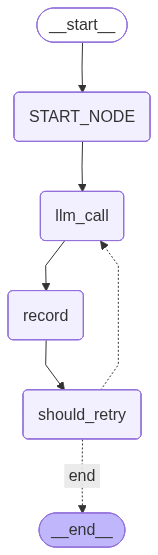

In [7]:
from graph_agent.llms.apis.iflow import IFlowApi
from graph_agent.llms.llm import LLMTool
llm = IFlowApi(model="qwen3-max", max_tokens=16384)
llm_tool = LLMTool("song", llm)
llm_tool.compile()


In [8]:
import time

begin_time = time.time()

responses = []
for i, input_entries in enumerate(inputs):
  print("="*100)
  print(f"Processing {i+1}/{len(inputs)}")
  start_time = time.time()
  prompt = generate_prompt(input_entries)
  response = llm_tool.invoke({"prompt": prompt})
  responses.append(response)
  print(f"Time taken: {time.time() - start_time} seconds")

print(len(responses))

end_time = time.time()
print(f"Total time taken: {end_time - begin_time} seconds")



Processing 1/59
2026-01-19 14:57:22 [info     ] node_start                     agent_name=song component=AgentGraph node_name=llm_call tags=['Control', 'Time'] work_path=/song/llm_call
2026-01-19 14:58:50 [info     ] node_end                       agent_name=song component=AgentGraph node_name=llm_call tags=['Control', 'Time'] work_path=/song/llm_call
2026-01-19 14:58:50 [info     ] node_start                     agent_name=song component=AgentGraph node_name=record tags=['Control', 'Time'] work_path=/song/record
2026-01-19 14:58:50 [info     ] node_end                       agent_name=song component=AgentGraph node_name=record tags=['Control', 'Time'] work_path=/song/record
2026-01-19 14:58:50 [info     ] node_start                     agent_name=song component=AgentGraph node_name=should_retry tags=['Control', 'Time'] work_path=/song/should_retry
2026-01-19 14:58:50 [info     ] node_end                       agent_name=song component=AgentGraph node_name=should_retry tags=['Control',

In [9]:
with open("./extraction.0118.json", "w", encoding="utf-8") as f:
  json.dump(responses, f, ensure_ascii=False, indent=2)

读取提取结果并进行分析归纳

In [17]:
import json
import re
with open("./extraction.0118.json", "r", encoding="utf-8") as f:
  responses = json.load(f)

def load_json_string(input: str):
  pattern = r'```json\s*\n(.*?)\n\s*```'
  matches = re.findall(pattern, input, re.DOTALL)
  json_str = ""
  if len(matches) >= 1:
    json_str = matches[0]
  else:
    json_str = input

  return json.loads(json_str)

contents = []
for i, response in enumerate(responses):
  try:
    content = response["response"]["response"]["choices"][0]["message"]["content"]
    obj = load_json_string(content)
    contents.append(obj)
  except Exception as e:
    print(f"error in response #{i}: {str(e)}")
    continue

print(len(contents))
with open("./reorganized-contents.0119.json", "w", encoding="utf-8") as f:
  json.dump(contents, f, ensure_ascii=False, indent=2)

entries = {}
with open("../data/refined_tables/第八至十编-表格化结果.json", "r", encoding="utf-8") as f:
  data = json.load(f)
for entry in data:
  entries[entry["name"]] = {
    "name": entry["name"],
    "class": [],
    "events": [], # 重要时间点
    # 机构属性
    "parent": [], # 上级机构
    "subordinate": [], # 下级机构
    "employees": [], # 编制
    # 职官属性
    "office": [], # 隶属机构
  }

def insert_class(item, entries):
  try:
    target = item["target"]
    entry_class = item["class"]
    cite = item["cite"]
  except Exception as e:
    print('Bad Class Format', e)
    print(json.dumps(item, ensure_ascii=False, indent=2))
    return {
      "error": f"Bad Class Format: {e}",
      "item": item
    }
  
  if target in entries:
    entries[target]["class"].append([entry_class, cite])
    return True
  else:
    print(f"No such target {target} in class_type")
    print(json.dumps(item, ensure_ascii=False, indent=2))
    return {
      "error": f"Unknown Target Entry in Class: {target}",
      "item": item
    }

# 好像在提示词中都没有给例子，不知道具体的结果会怎么样，之后再调整
def insert_hierarchy(item, entries):
  try:
    parent = item["parent"]
    subordinate = item["subordinate"]
    cite = item["cite"]
  except Exception as e:
    print('Bad Event Hierarchy', e)
    print(json.dumps(item, ensure_ascii=False, indent=2))
    return {
      "error": f"Bad Hierarchy Format: {e}",
      "item": item
    }
    
  if parent in entries:
    entries[parent]["subordinate"].append([subordinate, cite])
    return True
  else:
    print(f"No such target {parent} in hierarchy_type")
    print(json.dumps(item, ensure_ascii=False, indent=2))
    return {
      "error": f"Unknown Parent Entry in Hierarchy: {parent}",
      "item": item
    }

def insert_staff(item, entries):
  try:
    office = item["office"]
    employees = item["employees"]
    cite = item["cite"]
  except Exception as e:
    print('Bad Staff Format', e)
    print(json.dumps(item, ensure_ascii=False, indent=2))
    return {
      "error": f"Bad Staff Format: {e}",
      "item": item
    }
    
  if office in entries:
    entries[office]["employees"].append([employees, cite])
    return True
  else:
    print(f"No such office {office} in staff_type")
    print(json.dumps(item, ensure_ascii=False, indent=2))
    return {
      "error": f"Unknown Office Entry in Staff: {office}",
      "item": item
    }

def insert_event(item, entries):
  try:
    target = item["target"]
    time = item["time"]
    event = item["event"]
    cite = item["cite"]
  except Exception as e:
    print('Bad Event Format', e)
    print(json.dumps(item, ensure_ascii=False, indent=2))
    return {
      "error": f"Bad Event Format: {e}",
      "item": item
    }

  if target in entries:
    entries[target]["events"].append([time, event, cite])
    return True
  else:
    print(f"No such target {target} in event_type")
    print(json.dumps(item, ensure_ascii=False, indent=2))
    return {
      "error": f"Unknown Target Entry in Event: {target}",
      "item": item
    }

bad_items = []
for content in contents:
  for item in content:
    if item["type"] == "类别":
      f = insert_class(item, entries)
    elif item["type"] == "上下级机构":
      f = insert_hierarchy(item, entries)
    elif item["type"] == "编制":
      f = insert_staff(item, entries)
    elif item["type"] == "事件":
      f = insert_event(item, entries)
    else:
      print(f"Unknown type, {item["type"]}")
    if f != True:
      assert "error" in f
      bad_items.append(f)

print(len(bad_items))

with open("./reorganized.0119.json", "w", encoding="utf-8") as f:
  json.dump(entries, f, ensure_ascii=False, indent=2)
with open("./reorganized-bad.0119.json", "w", encoding="utf-8") as f:
  json.dump(bad_items, f, ensure_ascii=False, indent=2)


59
No such target 都部署 in hierarchy_type
{
  "type": "上下级机构",
  "parent": "都部署",
  "subordinate": "路分部署、钤辖、路分都监",
  "cite": {
    "text": "路分部署、钤辖以上许与都部署司同议军事。路分都监以下，得听都部署节制。",
    "ref": "《宋代官制辞典》，都部署司，text"
  }
}
No such target 都部署 in hierarchy_type
{
  "type": "上下级机构",
  "parent": "都部署",
  "subordinate": "路分马步军部署",
  "cite": {
    "text": "北宋一路多至十四、五员。听本路都部署节制。",
    "ref": "《宋代官制辞典》，路分马步军部署，text"
  }
}
No such office 部署司 in staff_type
{
  "type": "编制",
  "office": "部署司",
  "employees": "北宋诸路部署司设副部署，以官资稍浅者为之，任副贰之职，位于路钤辖之上。",
  "cite": {
    "text": "北宋诸路部署司设副部署，以官资稍浅者为之，任副贰之职。如“并代副部署孙廉趋延界并力击贼，仍令秦凤、鄜延、环庆部署左右援之。”位于路钤辖之上（《长编》卷52甲申、卷126丙戌）。",
    "ref": "《宋代官制辞典》，马步军副部署，text"
  }
}
No such target 经略、安抚、都部署司 in hierarchy_type
{
  "type": "上下级机构",
  "parent": "经略、安抚、都部署司",
  "subordinate": "都总管司走马承受公事",
  "cite": {
    "text": "真宗朝后隶经略、安抚、都部署司。",
    "ref": "《宋代官制辞典》，都总管司走马承受公事，职源与沿革"
  }
}
No such target 帅司 in hierarchy_type
{
  "type": "上下级机构",
  "parent": "帅司",
  "subordinate": "都总管司走马承